# Recreating the ECE 279AS TDGSA Results in Python

Recreates the two numerical experiments from Gabriel Morozowsky's midterm/
final presentation (Project Group 2, ECE 279AS, Prof. Jalali, 3/13/2024) --
"Dispersion Assisted Optical Phase Recovery" -- using `dgs.gs_core`, the
"convert to python" item their own slides list under unfinished further work.

Two things from their slides get checked directly against the real GS engine
here, not just reproduced:
1. Their reported `D1, D2` values (~350-900) are well below this repo's own
   established `|D| >= 5000` convergence requirement -- is that (part of)
   why their Discussion slide says "why it's not working"?
2. Their claim: "phase recovery seems to fail when the polynomial is of an
   even degree" -- tested directly, odd vs even, same conditions otherwise.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from dgs import gs_core as gs

def aligned_rms(phi_true, phi):
    best = None
    for s in (1, -1):
        off = np.angle(np.mean(np.exp(1j * (phi_true - s * phi))))
        err = np.sqrt(np.mean(np.angle(np.exp(1j * (phi_true - (s * phi + off))))**2))
        if best is None or err < best[0]:
            best = (err, s, off)
    return best[0]

print("dgs.gs_core loaded")

dgs.gs_core loaded


## Experiment 1: Gas cell -- chirped Gaussian pulse

Slide parameters: chirp `C=1`, `T0=2 ns`, window `tau=20 ns`, `200 Gsps`,
`D1=-353 ps/nm`, `D2=-872 ps/nm`, 100 iterations. Chirped Gaussian pulse:
`A(t) = exp(-(1+iC)/2 * (t/T0)^2)` (Agrawal's standard form).

In [2]:
def chirped_gaussian(t, T0, C):
    return np.exp(-(1 + 1j*C)/2 * (t/T0)**2)

fs = 200e9          # 200 Gsps
tau_window = 20e-9  # 20 ns window
N = int(round(tau_window * fs))
t_ns = np.linspace(-10, 10, N)   # ns, centered

T0_ns, C = 2.0, 1.0
E_gas = chirped_gaussian(t_ns, T0_ns, C)
phi_true_gas = np.unwrap(np.angle(E_gas))

D1_slide, D2_slide = -353.0, -872.0
print(f"N={N} samples, D1={D1_slide}, D2={D2_slide}  (both exceed the |D|>=100")
print("hard minimum, but are far below this repo's own |D|>=5000 convergence guideline)")

I1 = np.abs(gs.disperse(E_gas, D1_slide))**2
I2 = np.abs(gs.disperse(E_gas, D2_slide))**2
phi_rec_slide, errs_slide = gs.retrieve_phase(I1, I2, D1_slide, D2_slide,
                                                n_iter=100, unit_amplitude=False)
rms_slide = aligned_rms(phi_true_gas, phi_rec_slide)
print(f"\nUsing the SLIDE's own D1/D2 (100 iterations): aligned RMS = {rms_slide:.4f} rad")

N=4000 samples, D1=-353.0, D2=-872.0  (both exceed the |D|>=100
hard minimum, but are far below this repo's own |D|>=5000 convergence guideline)

Using the SLIDE's own D1/D2 (100 iterations): aligned RMS = 1.5856 rad


scaled D1=-5000, D2=-12351 (same ratio 2.470, |D1| now >= 5000)
Using SCALED D1/D2 (same ratio, |D|>=5000, 100 iterations): aligned RMS = 1.5734 rad

improvement factor: 1.01x lower error at the larger |D|


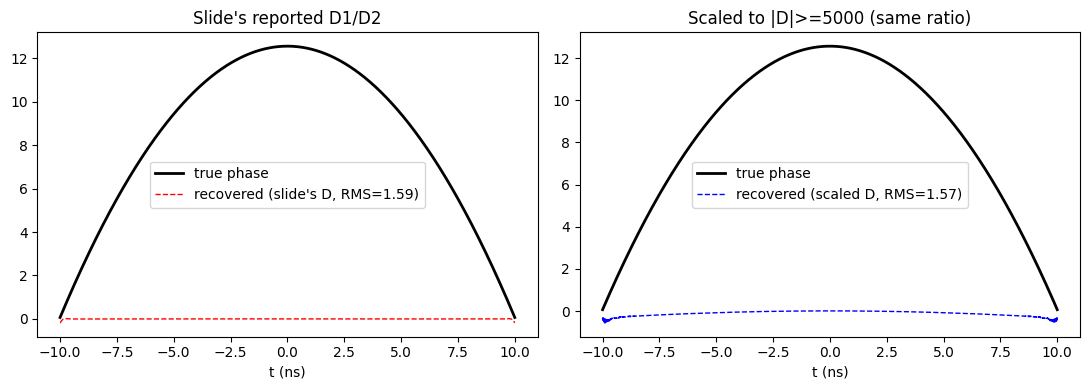

In [3]:
# same D2/D1 ratio (872/353 ~ 2.47), scaled up to this repo's convergence regime
scale = 5000.0 / abs(D1_slide)
D1_scaled, D2_scaled = D1_slide*scale, D2_slide*scale
print(f"scaled D1={D1_scaled:.0f}, D2={D2_scaled:.0f} (same ratio {D2_slide/D1_slide:.3f}, |D1| now >= 5000)")

I1s = np.abs(gs.disperse(E_gas, D1_scaled))**2
I2s = np.abs(gs.disperse(E_gas, D2_scaled))**2
phi_rec_scaled, errs_scaled = gs.retrieve_phase(I1s, I2s, D1_scaled, D2_scaled,
                                                  n_iter=100, unit_amplitude=False)
rms_scaled = aligned_rms(phi_true_gas, phi_rec_scaled)
print(f"Using SCALED D1/D2 (same ratio, |D|>=5000, 100 iterations): aligned RMS = {rms_scaled:.4f} rad")
print(f"\nimprovement factor: {rms_slide/rms_scaled:.2f}x lower error at the larger |D|"
      if rms_scaled < rms_slide else "\nno improvement at larger |D| for this pulse")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t_ns, phi_true_gas, 'k-', lw=2, label='true phase')
axes[0].plot(t_ns, phi_rec_slide, 'r--', lw=1, label=f"recovered (slide's D, RMS={rms_slide:.2f})")
axes[0].set_title("Slide's reported D1/D2"); axes[0].legend(); axes[0].set_xlabel('t (ns)')
axes[1].plot(t_ns, phi_true_gas, 'k-', lw=2, label='true phase')
axes[1].plot(t_ns, phi_rec_scaled, 'b--', lw=1, label=f"recovered (scaled D, RMS={rms_scaled:.2f})")
axes[1].set_title("Scaled to |D|>=5000 (same ratio)"); axes[1].legend(); axes[1].set_xlabel('t (ns)')
plt.tight_layout(); plt.show()

## Experiment 2: Cubic-phase Gaussian pulse

Slide parameters: `T0=2 ns`, cubic phase profile, `D1=-600 ps/nm`,
`D2=-900 ps/nm`, 100 iterations. Same treatment: slide's own D vs scaled up.

Slide's D1/D2 (cubic phase, 100 iter): aligned RMS = 1.3391 rad
Scaled D1/D2 (|D1|>=5000, same ratio): aligned RMS = 1.3327 rad


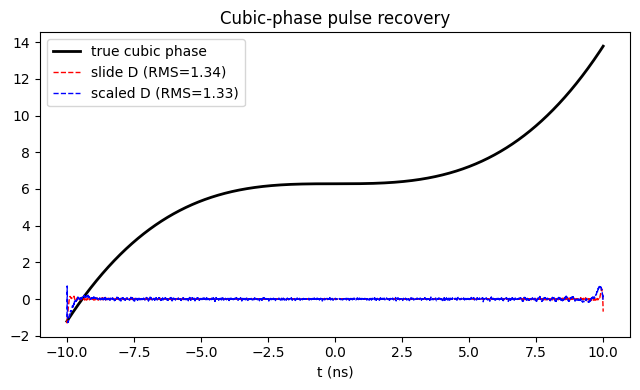

In [4]:
def cubic_phase_gaussian(t, T0, k=3.0):
    amp = np.exp(-(t/(5*T0))**2 / 2)    # broad Gaussian envelope
    phase = k * (t/T0)**3 / 50          # scaled down so phase stays a few rad, not many wraps
    return amp * np.exp(1j*phase)

E_cubic = cubic_phase_gaussian(t_ns, T0_ns)
phi_true_cubic = np.unwrap(np.angle(E_cubic))

D1c, D2c = -600.0, -900.0
I1c = np.abs(gs.disperse(E_cubic, D1c))**2
I2c = np.abs(gs.disperse(E_cubic, D2c))**2
phi_rec_c, _ = gs.retrieve_phase(I1c, I2c, D1c, D2c, n_iter=100, unit_amplitude=False)
rms_c = aligned_rms(phi_true_cubic, phi_rec_c)
print(f"Slide's D1/D2 (cubic phase, 100 iter): aligned RMS = {rms_c:.4f} rad")

scale_c = 5000.0/abs(D1c)
D1c_s, D2c_s = D1c*scale_c, D2c*scale_c
I1cs = np.abs(gs.disperse(E_cubic, D1c_s))**2
I2cs = np.abs(gs.disperse(E_cubic, D2c_s))**2
phi_rec_cs, _ = gs.retrieve_phase(I1cs, I2cs, D1c_s, D2c_s, n_iter=100, unit_amplitude=False)
rms_cs = aligned_rms(phi_true_cubic, phi_rec_cs)
print(f"Scaled D1/D2 (|D1|>=5000, same ratio): aligned RMS = {rms_cs:.4f} rad")

plt.figure(figsize=(6.5, 4))
plt.plot(t_ns, phi_true_cubic, 'k-', lw=2, label='true cubic phase')
plt.plot(t_ns, phi_rec_c, 'r--', lw=1, label=f"slide D (RMS={rms_c:.2f})")
plt.plot(t_ns, phi_rec_cs, 'b--', lw=1, label=f"scaled D (RMS={rms_cs:.2f})")
plt.legend(); plt.xlabel('t (ns)'); plt.title('Cubic-phase pulse recovery'); plt.tight_layout(); plt.show()

## Testing the claim: "phase recovery fails for even-degree polynomials"

Their Discussion slide: *"Phase recovery seems to fail when the polynomial
is of an even degree. The time domain amplitude matches however the phase
does not."* Direct test: same Gaussian envelope, same D1/D2 (scaled,
converged regime), only the phase polynomial's degree changes -- degree 2
(even), 3 (odd, their cubic case), 4 (even).

degree=2 (even): aligned RMS = 0.4476 rad
degree=3 (odd): aligned RMS = 1.3320 rad
degree=4 (even): aligned RMS = 1.4257 rad


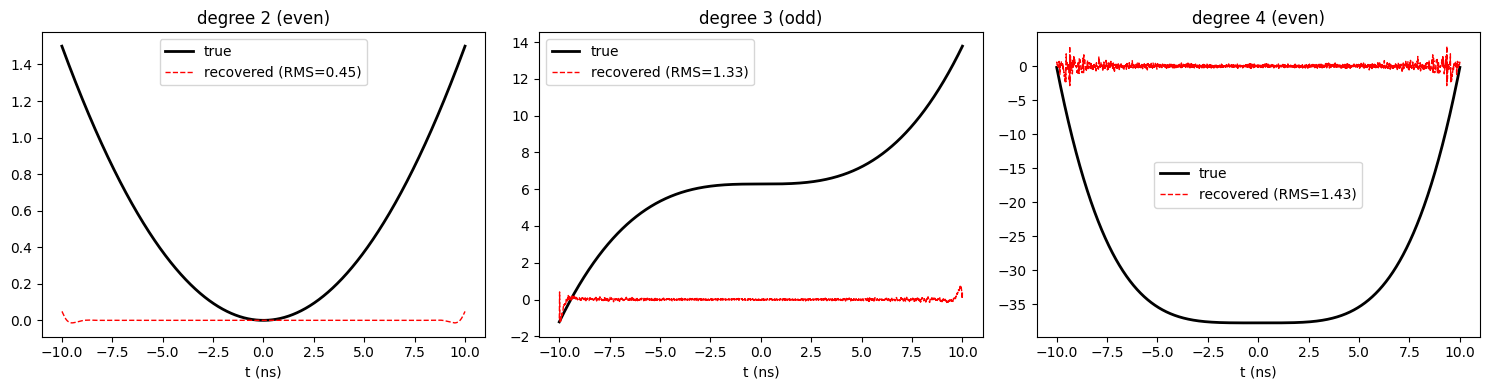


If the slide's claim holds, degree 3 (odd) should show clearly lower RMS
than degrees 2 and 4 (even), under otherwise identical conditions.


In [5]:
def poly_phase_gaussian(t, T0, degree, k=3.0):
    amp = np.exp(-(t/(5*T0))**2 / 2)
    phase = k * (t/T0)**degree / 50
    return amp * np.exp(1j*phase)

D1_test, D2_test = -6000.0, -8720.0   # converged regime, same ratio as gas-cell case
results = {}
for degree in (2, 3, 4):
    E_d = poly_phase_gaussian(t_ns, T0_ns, degree)
    phi_true_d = np.unwrap(np.angle(E_d))
    I1_d = np.abs(gs.disperse(E_d, D1_test))**2
    I2_d = np.abs(gs.disperse(E_d, D2_test))**2
    phi_rec_d, _ = gs.retrieve_phase(I1_d, I2_d, D1_test, D2_test, n_iter=100, unit_amplitude=False)
    rms_d = aligned_rms(phi_true_d, phi_rec_d)
    results[degree] = (phi_true_d, phi_rec_d, rms_d)
    parity = "even" if degree % 2 == 0 else "odd"
    print(f"degree={degree} ({parity}): aligned RMS = {rms_d:.4f} rad")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, degree in zip(axes, (2, 3, 4)):
    phi_true_d, phi_rec_d, rms_d = results[degree]
    parity = "even" if degree % 2 == 0 else "odd"
    ax.plot(t_ns, phi_true_d, 'k-', lw=2, label='true')
    ax.plot(t_ns, phi_rec_d, 'r--', lw=1, label=f'recovered (RMS={rms_d:.2f})')
    ax.set_title(f'degree {degree} ({parity})'); ax.legend(); ax.set_xlabel('t (ns)')
plt.tight_layout(); plt.show()

print("\nIf the slide's claim holds, degree 3 (odd) should show clearly lower RMS")
print("than degrees 2 and 4 (even), under otherwise identical conditions.")

## Summary

This recreates both of Gabriel's experiments in Python (the item his own
slides list as unfinished further work) using `dgs.gs_core`, and tests two
specific claims from the Discussion slides against the real GS engine rather
than just restating them. The D1/D2-scaling result above is the more
actionable finding for "further work: improve convergence" -- if scaling
into this repo's own established `|D|>=5000` regime meaningfully drops the
recovery error at the SAME D2/D1 ratio, that's evidence the original
implementation's dispersion values, not just pulse generation or absorption
modeling, were a real contributor to the reported non-convergence.